In [1]:
from datetime import datetime
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
from cartopy.feature import LAND

## Load the dataframe from a feather file
### Columns:
* i - image index
* g - trajectory index
* d - datetime
* x - X-coordinate
* y - Y-coordinate
* q - quality

In [2]:
df = pd.read_feather('points.feather')
df

,i,g,d,x,y,q
0,1,142,2020-01-01 01:56:02,-470712.687284,4.701978e+05,0.000000
1,1,99,2020-01-01 01:56:02,-410439.019536,1.992613e+05,0.000000
2,1,59,2020-01-01 01:56:02,-442025.101585,2.561483e+05,0.000000
3,1,98,2020-01-01 01:56:02,-412801.621492,2.085297e+05,0.000000
4,1,97,2020-01-01 01:56:02,-419165.596831,2.136786e+05,0.000000
...,...,...,...,...,...,...
12712989,13743,1557521,2020-04-30 20:56:27,-456237.114884,1.315839e+06,0.527267
12712990,13743,1587002,2020-04-30 20:56:27,-284841.392825,1.583561e+06,0.728640
12712991,13743,1587011,2020-04-30 20:56:27,-323448.181239,1.592736e+06,0.726223
12712992,13743,1587012,2020-04-30 20:56:27,-314584.630905,1.588716e+06,0.693757


## Plot all points for a given date range

166 images in the date range
42889 trajectories in the date range


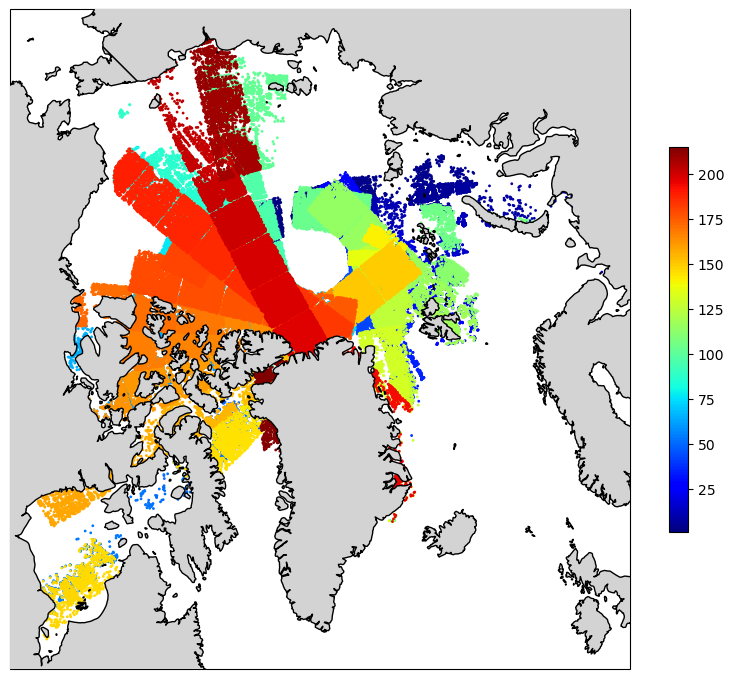

In [3]:
# Select a date range
date0 = datetime(2020,1,1)
date1 = datetime(2020,1,3)

# Filter the dataframe for the selected date range
df1 = df[(df.d >= date0) & (df.d <= date1)]

# Find unique images and trajectories in the filtered dataframe
img_idx = np.unique(df1.i)
trj_idx = np.unique(df1.g)
print(len(img_idx), 'images in the date range')
print(len(trj_idx), 'trajectories in the date range')

# Plot all points and color them by image index
nps = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70.0)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1, 1, 1, projection=nps)
scat = ax.scatter(df1.x, df1.y, c=df1.i, cmap='jet', s=1)
plt.colorbar(scat, ax=ax, shrink=0.5)
ax.add_feature(LAND, zorder=10, edgecolor='black', facecolor='lightgray')
plt.show()

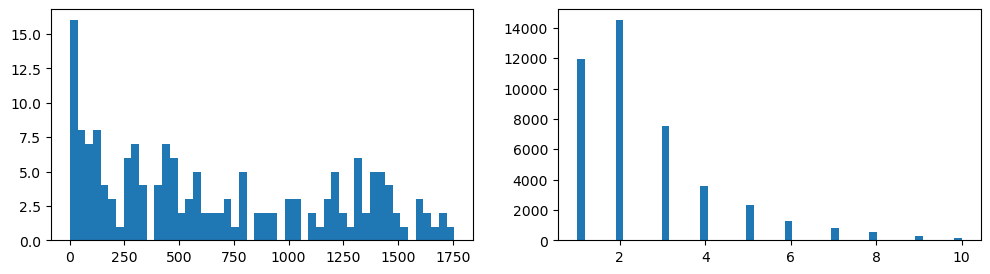

In [7]:
# Calculate the number of points per image and per trajectory
points_per_image = df1.groupby('i').size()
points_per_trajectory = df1.groupby('g').size()
fig, axs = plt.subplots(1,2, figsize=(12,3))
axs[0].hist(points_per_image, bins=50)
axs[1].hist(points_per_trajectory, bins=50)
plt.show()

## Plot the longest trajectories

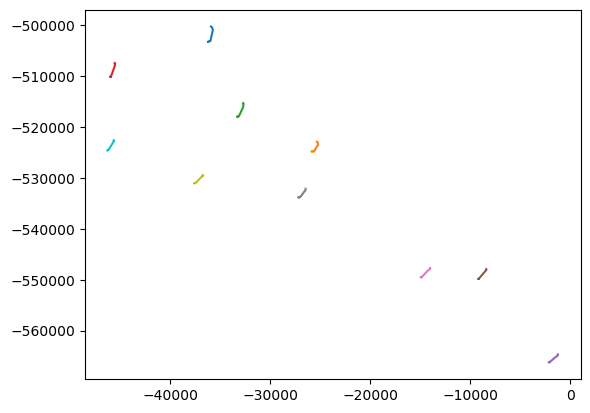

In [5]:
# Find IDs of trajectories with at least 10 points and plot the first 10 of them
long_trajectory_ids = points_per_trajectory[points_per_trajectory >=10].index.values
for g, grp in list(df1[df1.g.isin(long_trajectory_ids)].groupby('g'))[:10]:
    plt.plot(grp.x, grp.y, '-')

## Plot ice drift vectors

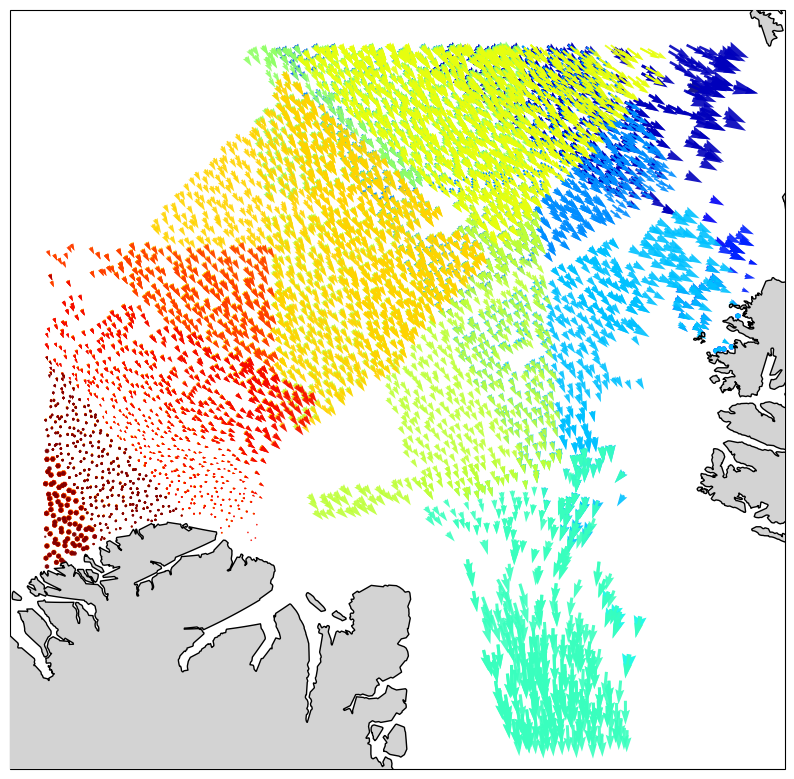

In [6]:
# Set date range for start of vectors
date00 = datetime(2020,1,1,0,0,0)
date01 = datetime(2020,1,2,0,0,0)

# Set date range for end of vectors
date10 = datetime(2020,1,2,0,0,0)
date11 = datetime(2020,1,3,0,0,0)

# Set limits for x and y axes
xlim = [0, 1e6]
ylim = [-1e6, 0]

# Filter the dataframe for the two date ranges and within the specified x and y limits
df_0 = df[(df.d >= date00) & (df.d <= date01) & (df.x > xlim[0]) & (df.x < xlim[1]) & (df.y > ylim[0]) & (df.y < ylim[1])]
df_1 = df[(df.d >= date10) & (df.d <= date11) & (df.x > xlim[0]) & (df.x < xlim[1]) & (df.y > ylim[0]) & (df.y < ylim[1])]

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1, 1, 1, projection=nps)

# Loop through unique images in the first date range and unique images in the second date range
for ii0, img_id_0 in enumerate(df_0.i.unique()):
    colors = plt.cm.jet(np.linspace(0, 1, len(df_0.i.unique())))
    # Filter the dataframe for the current image in the first date range
    df_0_img = df_0[df_0.i == img_id_0]
    for ii1, img_id_1 in enumerate(df_1.i.unique()):
        # Filter the dataframe for the current image in the second date range
        df_1_img = df_1[df_1.i == img_id_1]
        # Find common trajectory IDs between the two images and their indices
        common_trj_ids, i0, i1 = np.intersect1d(df_0_img.g.unique(), df_1_img.g.unique(), return_indices=True)
        if len(common_trj_ids) > 0:
            # Get start and end coordinates and compute velcocity
            x0 = df_0_img.iloc[i0].x.values
            y0 = df_0_img.iloc[i0].y.values
            d0 = df_0_img.iloc[i0[0]].d
            x1 = df_1_img.iloc[i1].x.values
            y1 = df_1_img.iloc[i1].y.values
            d1 = df_1_img.iloc[i1[0]].d
            u = (x1 - x0) / (d1 - d0).total_seconds() # m/s
            v = (y1 - y0) / (d1 - d0).total_seconds() # m/s
            # Plot the velocity vectors using quiver, colorize by the image ID of the first date range
            ax.quiver(x0, y0, u, v, angles='xy', scale_units='xy', scale=0.00001, color=colors[ii0], alpha=0.9, label=df_0_img.d.iloc[0].strftime('%H:%M:%S'))
ax.add_feature(LAND, zorder=10, edgecolor='black', facecolor='lightgray')
plt.show()
